In [2]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms

import pytorch_lightning as pl
from torch.utils.data import DataLoader, random_split

import torch.optim as optim
import torch.ao.quantization as quant
import pytorch_lightning as pl
from torchvision.models import resnet18

import torch_tensorrt

import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import os
import sys
import time

sys.path.append(str(Path("../src").resolve()))
from spectogram_datamodule import SpektogramDataModule
from custom_transform import ShuffleChannels

FOLDER_PATH = Path(r"../spectogram_wieliczka")
TEST_FOLDER_PATH = Path(r"../spectogram_ziemowit")
NUM_CLASSES = 2

Unable to import quantization op. Please install modelopt library (https://github.com/NVIDIA/TensorRT-Model-Optimizer?tab=readme-ov-file#installation) to add support for compiling quantized models
Unable to import quantize op. Please install modelopt library (https://github.com/NVIDIA/TensorRT-Model-Optimizer?tab=readme-ov-file#installation) to add support for compiling quantized models
TensorRT-LLM is not installed. Please install TensorRT-LLM or set TRTLLM_PLUGINS_PATH to the directory containing libnvinfer_plugin_tensorrt_llm.so to use converters for torch.distributed ops


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


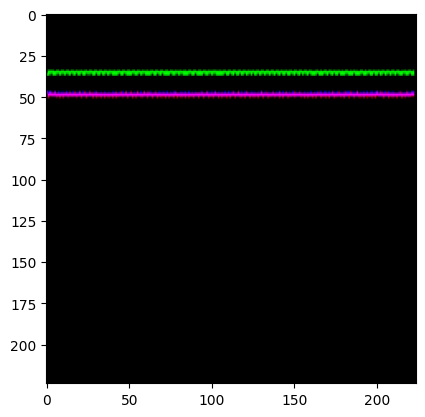

In [3]:
spectrogram_transforms = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((224, 224)), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
    ShuffleChannels(0.5)
])

dm_wieliczka = SpektogramDataModule(FOLDER_PATH, spectrogram_transforms)
dm_wieliczka.setup()

dm_ziemowit = SpektogramDataModule(TEST_FOLDER_PATH, spectrogram_transforms, test_split=1, num_workers=0)
dm_ziemowit.setup()


plt.imshow(next(iter(dm_wieliczka.train_dataloader()))[0][3].numpy().transpose(1, 2, 0))

In [4]:
class LitResNet(pl.LightningModule):
	def __init__(self, num_classes=10, lr=1e-3):
		super().__init__()
		self.save_hyperparameters()
		self.lr = lr

		self.model = resnet18(pretrained=False, num_classes=num_classes)
		self.criterion = nn.CrossEntropyLoss()


		self.train_loss_history = []
		self.train_acc_history = []

		self.val_loss_history = []
		self.val_acc_history = []

		self.test_loss_history = []
		self.test_acc_history = []

	def forward(self, x):
		return self.model(x)


	def training_step(self, batch, batch_idx):
		x, y = batch
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()

		self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
		self.log("train_acc", acc, on_step=True, on_epoch=True, prog_bar=True)

		self.train_loss_history.append(loss.detach().cpu())
		self.train_acc_history.append(acc.detach().cpu())

		return loss


	def validation_step(self, batch, batch_idx):
		x, y = batch
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()
		self.val_loss_history.append(loss.detach().cpu())
		self.val_acc_history.append(acc.detach().cpu())
		self.log("val_loss", loss, on_epoch=True, prog_bar=True)
		self.log("val_acc", acc, on_epoch=True, prog_bar=True)
		return loss

	def test_step(self, batch, batch_idx):
		x, y = batch
		start_time = time.time()  
		
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()
		
		end_time = time.time()  
		
		batch_time = end_time - start_time  
		batch_size = x.size(0)
		fps = batch_size / batch_time  
		
		self.test_loss_history.append(loss.detach().cpu())
		self.test_acc_history.append(acc.detach().cpu())

		self.log("test_loss", loss, on_epoch=True, prog_bar=True)
		self.log("test_acc", acc, on_epoch=True, prog_bar=True)
		self.log("test_fps", fps, on_epoch=True, prog_bar=True)  
		
		return loss

	def configure_optimizers(self):
		return optim.SGD(self.parameters(), lr=self.lr, momentum=0.9)

In [5]:
model = LitResNet(num_classes=NUM_CLASSES, lr=1e-3)

trainer = pl.Trainer(
    precision=16,
    accelerator='gpu',
    devices=1,
    max_epochs=50
)

trainer.fit(model, dm_wieliczka)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 3080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model     | ResNet           | 11.2 M | train | 0    
1 | criterion | CrossEntropyLoss | 0      | train | 0    
--------------------------

Epoch 49: 100%|██████████| 5/5 [00:02<00:00,  2.00it/s, v_num=7, train_loss_step=0.006, train_acc_step=1.000, val_loss=0.0245, val_acc=1.000, train_loss_epoch=0.0242, train_acc_epoch=0.993]   

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 5/5 [00:03<00:00,  1.37it/s, v_num=7, train_loss_step=0.006, train_acc_step=1.000, val_loss=0.0245, val_acc=1.000, train_loss_epoch=0.0242, train_acc_epoch=0.993]


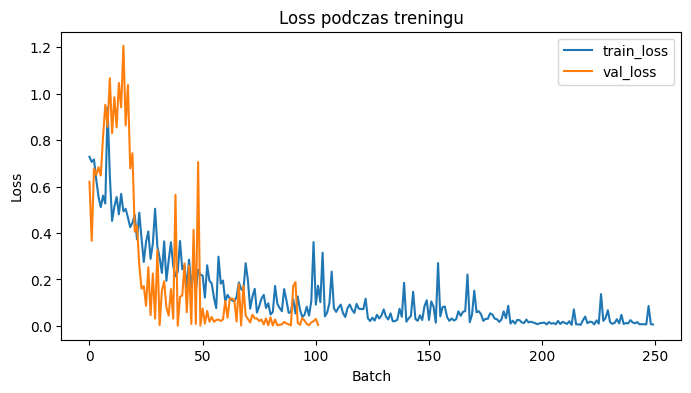

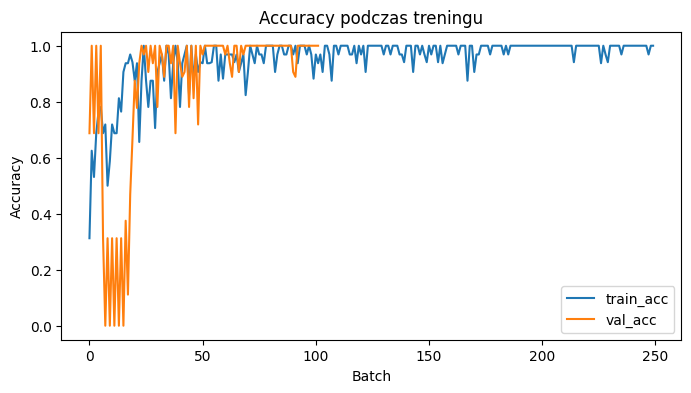

In [6]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(8,4))
plt.plot(model.train_loss_history, label="train_loss")
plt.plot(model.val_loss_history, label="val_loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Loss podczas treningu")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(8,4))
plt.plot(model.train_acc_history, label="train_acc")
plt.plot(model.val_acc_history, label="val_acc")
plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.title("Accuracy podczas treningu")
plt.legend()
plt.show()


In [7]:
trainer.test(model, dm_ziemowit)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  5.14it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.32258063554763794
        test_fps            172.78492736816406
        test_loss            5.227114677429199
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 5.227114677429199,
  'test_acc': 0.32258063554763794,
  'test_fps': 172.78492736816406}]

In [ ]:
# sample = next(iter(dm_ziemowit.test_dataloader()))[0][0]
# sample = sample.unsqueeze(0).cuda().half() 

# model.eval().cuda()

# trt_model = torch_tensorrt.compile(
#     model,
#     inputs=[torch_tensorrt.Input(sample.shape, dtype=torch.half)],
#     enabled_precisions={torch.half},
#     workspace_size=1 << 20
# )

# with torch.no_grad():
#     out = trt_model(sample)
# print(out.shape)

In [ ]:
next(iter(dm_ziemowit.test_dataloader()))[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
sample = next(iter(dm_ziemowit.test_dataloader()))[0][0].unsqueeze(0).half()
torch.onnx.export(
    model.half().eval().cuda(),
    sample.cuda(),
    "jetson_nano_nn/models/resnet18.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=17,
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}}
)

NameError: name 'dm_ziemowit' is not defined